In [1]:
import nltk
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Error loading movie_reviews: <urlopen error [Errno 8]
[nltk_data]     nodename nor servname provided, or not known>
[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading wordnet: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading punkt: <urlopen error [Errno 8] nodename nor
[nltk_data]     servname provided, or not known>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

In [2]:
from nltk.corpus import movie_reviews
import pandas as pd
import numpy as np
reviews = []
for fileid in movie_reviews.fileids():
    label = 1 if fileid.startswith('pos') else 0
    text = movie_reviews.raw(fileid)
    reviews.append({'text' : text, 'label' : label})
df = pd.DataFrame(reviews)
print(df.shape)
print(df['label'].value_counts())
print(df.head())
print(f'\nExample review\n {df['text'][0][:500]}')

(2000, 2)
label
0    1000
1    1000
Name: count, dtype: int64
                                                text  label
0  plot : two teen couples go to a church party ,...      0
1  the happy bastard's quick movie review \ndamn ...      0
2  it is movies like these that make a jaded movi...      0
3   " quest for camelot " is warner bros . ' firs...      0
4  synopsis : a mentally unstable man undergoing ...      0

Example review
 plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt


word count statistics: 
        count     mean         std    min    25%    50%     75%     max
label                                                                  
0      1000.0  705.630  296.729759   17.0  510.0  668.5  848.25  2181.0
1      1000.0  787.051  352.799881  130.0  543.5  731.5  957.25  2678.0


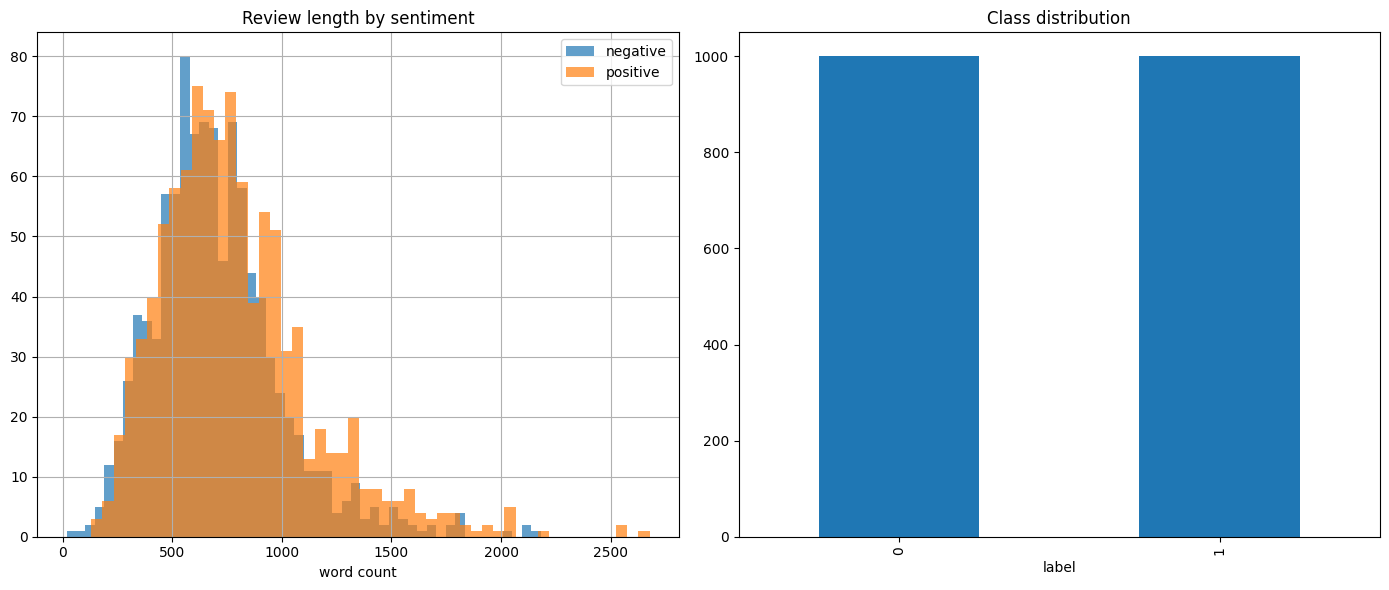

In [3]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(lambda x: len(x))

print('word count statistics: ')
print(df.groupby(df['label'])['word_count'].describe())

import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.subplot(1,2,1)
df[df['label']==0]['word_count'].hist(bins = 50,alpha = 0.7,label = 'negative')
df[df['label']==1]['word_count'].hist(bins = 50,alpha = 0.7,label = 'positive')
plt.xlabel('word count')
plt.title('Review length by sentiment')
plt.legend()

plt.subplot(1,2,2)
df['label'].value_counts().plot(kind = 'bar')
plt.title('Class distribution')
plt.tight_layout()
plt.show()

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '',text)

    tokens = text.split()

    tokens = [t for t in tokens if t not in stopwords]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [5]:
sample = df['text'][0][:500]
print(sample)
print()
print(preprocess_text(sample))

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare whats deal watch movie sorta find critique mindfuck movie teen generation touch cool idea present bad package make review even harder one write since generally applaud film attempt


In [6]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [7]:
print(f'original avg word count {df['word_count'].mean():.0f}')
df['word_count_clean'] = df['clean_text'].apply(lambda x: len(x.split()))
print(f'avg word count after processing {df['word_count_clean'].mean():.0f}')
print(f'words removed {(df['word_count'].mean() - df['word_count_clean'].mean())/ df['word_count'].mean() * 100:.0f}%')


original avg word count 746
avg word count after processing 352
words removed 53%


In [8]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
Y = df['label']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,stratify=Y,random_state = 42)
print(f'train size {len(X_train)}')
print(f'test size {len(X_test)}')
print(f'train class imbalance {Y_train.value_counts().to_dict()}')
print(f'train class imbalance {Y_test.value_counts().to_dict()}')

train size 1600
test size 400
train class imbalance {1: 800, 0: 800}
train class imbalance {0: 200, 1: 200}


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizers = CountVectorizer(max_features = 10000)

X_train_bow = bow_vectorizers.fit_transform(X_train)
X_test_bow = bow_vectorizers.transform(X_test)
print(f'BOW matrix shape {X_train_bow.shape}')
print(f'Matrix type: {type(X_train_bow)}')
print(f'Sparsity: {1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.3f}')

vocab = bow_vectorizers.get_feature_names_out()
print(f'first 20 words {vocab[:20]}')
print(f'last 20 words {vocab[-20:]}')

BOW matrix shape (1600, 10000)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 0.977
first 20 words ['aaron' 'abandon' 'abandoned' 'abby' 'abduction' 'aberdeen' 'ability'
 'able' 'ably' 'aboard' 'abolitionist' 'abortion' 'abound' 'abraham'
 'abrasive' 'abrupt' 'abruptly' 'absence' 'absent' 'absolute']
last 20 words ['zack' 'zahn' 'zane' 'zany' 'zellweger' 'zemeckis' 'zero' 'zest' 'zeta'
 'zetajones' 'zinger' 'zoe' 'zombie' 'zone' 'zoolander' 'zoom' 'zorro'
 'zucker' 'zwick' 'zwicks']


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features = 10000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'tf-idf matrix {X_train_tfidf.shape}')
sample_idx = 0 
bow_values = X_train_bow[sample_idx].toarray()[0]
tfidf_values = X_train_tfidf[sample_idx].toarray()[0]

top_tfidf_idx = tfidf_values.argsort()[-10:][::-1]
print('top 10 words by TF-IDF scores:')
for idx in top_tfidf_idx:
    print(f'vocab:{vocab[idx]} BOW:{bow_values[idx]} TF-IDF:{tfidf_values[idx]:.3f}')

tf-idf matrix (1600, 10000)
top 10 words by TF-IDF scores:
vocab:ryan BOW:7 TF-IDF:0.332
vocab:private BOW:7 TF-IDF:0.317
vocab:tom BOW:5 TF-IDF:0.200
vocab:saving BOW:4 TF-IDF:0.190
vocab:war BOW:5 TF-IDF:0.183
vocab:damon BOW:3 TF-IDF:0.177
vocab:excellent BOW:4 TF-IDF:0.164
vocab:spielberg BOW:3 TF-IDF:0.164
vocab:battle BOW:4 TF-IDF:0.156
vocab:hank BOW:3 TF-IDF:0.153


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report

results = {}
nb_bow = MultinomialNB().fit(X_train_bow,Y_train)
nb_bow_preds = nb_bow.predict(X_test_bow)
results['NaiveBayes_BOW'] = accuracy_score(Y_test,nb_bow_preds)

nb_tfdif = MultinomialNB().fit(X_train_tfidf,Y_train)
nb_tfdif_preds = nb_tfdif.predict(X_test_tfidf)
results['NaiveBayes_TF-IDF'] = accuracy_score(Y_test,nb_tfdif_preds)

lr_bow = LogisticRegression(max_iter = 1000,random_state = 42).fit(X_train_bow,Y_train)
lr_bow_preds = lr_bow.predict(X_test_bow)
results['LogReg_BOW'] = accuracy_score(Y_test,lr_bow_preds)

lr_tfidf = LogisticRegression(max_iter = 1000,random_state = 42).fit(X_train_tfidf,Y_train)
lr_tfidf_preds = lr_tfidf.predict(X_test_tfidf)
results['LogReg_TF-IDF'] = accuracy_score(Y_test,lr_tfidf_preds)

for model, acc in sorted(results.items(),  key=lambda x: x[1], reverse = True):
    print(f'{model}:{acc:.4f}')


LogReg_BOW:0.8500
LogReg_TF-IDF:0.8300
NaiveBayes_BOW:0.8100
NaiveBayes_TF-IDF:0.8000


In [12]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficient = lr_bow.coef_[0]

top_15_positive = coefficient.argsort()[-15:][::-1]
top_15_negative = coefficient.argsort()[:15]
print('top 15 most positive words')
for idx in top_15_positive:
    print(f'{feature_names[idx]}:{coefficient[idx]:.4f}')
print()
for idx in top_15_negative:
    print(f'{feature_names[idx]}:{coefficient[idx]:.4f}')

top 15 most positive words
overall:0.5027
great:0.4752
well:0.4577
excellent:0.4482
perfect:0.4388
fun:0.4323
matrix:0.4220
hilarious:0.4119
together:0.4090
quite:0.4068
job:0.4031
entertaining:0.3940
violence:0.3736
back:0.3718
performance:0.3629

bad:-0.7699
worst:-0.5926
nothing:-0.5689
unfortunately:-0.5263
supposed:-0.5162
waste:-0.4909
attempt:-0.4642
awful:-0.4491
boring:-0.4382
script:-0.4319
mess:-0.4252
look:-0.4242
fall:-0.4077
ridiculous:-0.4044
plot:-0.3938


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report

xgb_bow = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 4,
    eval_metric = 'logloss',
    verbosity = 0,
    random_state = 42
).fit(X_train_bow,Y_train)
xgb_bow_preds = xgb_bow.predict(X_test_bow)
results['XGBoost_BOW'] = accuracy_score(Y_test,xgb_bow_preds)

xgb_tfidf = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 4,
    eval_metric = 'logloss',
    verbosity = 0,
    random_state = 42
).fit(X_train_tfidf,Y_train)
xgb_tfidf_preds = xgb_tfidf.predict(X_test_tfidf)
results['XGBoost_TFIDF'] = accuracy_score(Y_test,xgb_tfidf_preds)



In [14]:
for model,acc in sorted(results.items(),key = lambda x: x[1],reverse = True):
    print(f'{model}: {acc}')

LogReg_BOW: 0.85
XGBoost_TFIDF: 0.8475
XGBoost_BOW: 0.835
LogReg_TF-IDF: 0.83
NaiveBayes_BOW: 0.81
NaiveBayes_TF-IDF: 0.8


In [15]:
best_preds = lr_bow_preds
print('best model = Logistic Regression + BOW')
print(classification_report(Y_test,best_preds,target_names=['negative','postive']))

best model = Logistic Regression + BOW
              precision    recall  f1-score   support

    negative       0.87      0.82      0.85       200
     postive       0.83      0.88      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [16]:
test_df = pd.DataFrame({
    'text': X_test.values,
    'actual' : Y_test.values,
    'predicted': best_preds
})

In [17]:
errors = test_df[test_df['actual'] != test_df['predicted']]

print(f'total errors {len(errors)} out of {len(test_df)}')
print(f'error rate {len(errors)/len(test_df)*100:.2f}%\n')

false_positives = errors[errors['predicted'] == 1]
print(f'false positive (predicted positive but actually negative) {len(false_positives)}')
print('example of false positive:')
print(false_positives['text'].iloc[0][:400])

print()

false_negatives = errors[errors['predicted'] == 0]
print(f'false negative (predicted negative but actually positive) {len(false_negatives)}')
print('example of false negative')
print(false_negatives['text'].iloc[0][:400])

total errors 60 out of 400
error rate 15.00%

false positive (predicted positive but actually negative) 35
example of false positive:
running time approximately hr min reviewed jack choo rating movie start rather seenish opening sequence rather cool set mood thing come story propels audience neoreality somewhat close conscious reality laced weird tinge blue red existenz actually name new virtualreality game supposedly vr game highly popular considered legaldrug neoreality leigh ultimate game creator introduces ultimate gameexper

false negative (predicted negative but actually positive) 25
example of false negative
friend went live usa complain one thing country different one depicted hollywood movie especially true end somewhere unexplored land los angeles new york find big surprise majority people vote republican go church every sunday usually dont tolerate liberal attitude taken granted average american film rude awakening however happen another direction conservative people sometim

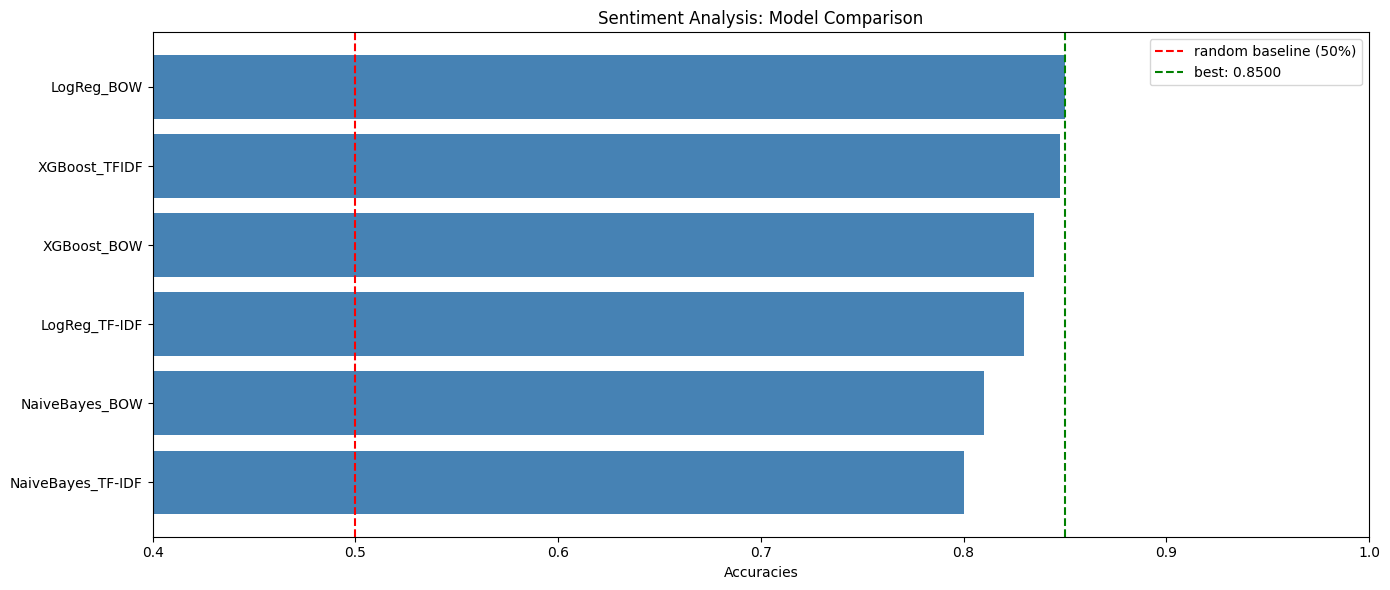

In [38]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

sorted_pairs = sorted(zip(accuracies,models))
accuracies,models = zip(*sorted_pairs)


plt.figure(figsize=(14,6))
bars = plt.barh(models,accuracies,color = 'steelblue')
plt.axvline(x=0.5,linestyle = '--',color = 'red',label = 'random baseline (50%)')
plt.axvline(x=max(accuracies),linestyle='--',color='green',label = f'best: {max(accuracies):.4f}')
plt.xlabel('Accuracies')
plt.title('Sentiment Analysis: Model Comparison')
plt.xlim(0.4,1.0)
plt.legend()
plt.tight_layout()
plt.show()